# T34 — Joining PBDB occurrences with Macrostrat lithology in paleo-coordinates

**Pull a taxonomic group's fossil occurrences from the Paleobiology Database (PBDB) and the contemporaneous host-rock lithology context from Macrostrat (https://macrostrat.org/), reconstruct each occurrence to its mid-age paleo-position with `gplately`, and plot the joined record coloured by lithology. The suite's first joined-database notebook combining paleontological and stratigraphic data.**

## What this notebook produces

PBDB (paleobiodb.org) is the community fossil-occurrence database — each row a taxonomic occurrence at a known locality with a known age range. Macrostrat (macrostrat.org, used in T33) is the formation-resolution stratigraphic database — each row a named geological unit with location, age range, and lithology classification. PBDB and Macrostrat are linked by collection ID where the occurrence's host rock is also a named Macrostrat unit.

This notebook does the join:

1. Pull PBDB occurrences for a taxonomic group (default: Cambrian–Ordovician brachiopods, ~520–440 Ma).
2. For each occurrence, query Macrostrat for the host unit's lithology classification (siliciclastic / carbonate / mixed).
3. Reconstruct each occurrence to its mid-age paleo-position with `gplately`.
4. Render a paleo-Earth map at one representative target age with one dot per occurrence, coloured by lithology classification — siliciclastics in orange, carbonates in blue.

The result shows the litho-biogeography simultaneously: where in paleo-space carbonate-platform brachiopods sat versus where siliciclastic-shelf brachiopods sat at the same age. Complements T33 (Macrostrat sedimentary units in paleo-position) by adding the biotic dimension.

**Audience**: undergrad → postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Combine queries from two related earth-science REST APIs (PBDB + Macrostrat) into a single tidy table.
- Reconstruct a population of paleontological localities to a target age with `gplately`.
- Render a categorical paleo-Earth map with explicit per-class colour coding.

## Prerequisites and runtime

- Plate model: Cao 2024 (deep-time, covers Cambrian–Ordovician).
- APIs: PBDB (https://paleobiodb.org/data1.2/) and Macrostrat (https://macrostrat.org/api/). Both free, no key, JSON responses.
- Python: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`, `requests`.
- Runtime: ~30 s. Both APIs are usually fast; subject to upstream rate limits.

## Data availability

This notebook pulls data live from two open community APIs at runtime:

> **PBDB**: Alroy, J. et al. (Paleobiology Database community). https://paleobiodb.org/
> Carrasco, M.A. et al. (2018). The Paleobiology Database. https://doi.org/10.21105/joss.01270

> **Macrostrat**: Peters, S.E. et al. (2018). Macrostrat: A platform for geological data integration and deep-time Earth crust research. *Geochem. Geophys. Geosys.* 19, 1393–1409. https://doi.org/10.1029/2018GC007467

Neither API requires a key. Both are CC-BY for downstream re-use; please cite the underlying contributors via the API's standard citation field where available.

The pattern of joining PBDB and Macrostrat for paleo-spatial work was popularised by Adam Kocsis's R-side template at https://plannapus.github.io/blog/2020-11-09.html. This is the Python equivalent.

In [7]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import os, numpy as np, pandas as pd, requests
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from pathlib import Path
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change taxonomic group, age window, and target time

In [8]:
# === USER CONFIGURATION =====================================================
MODEL_NAME       = "Merdith2021"   # paleomag frame; anchor 0 = spin axis
TAXON_NAME       = "Brachiopoda"
AGE_RANGE_MA     = (440.0, 520.0)
TARGET_TIME      = 470.0          # Floian / Dapingian boundary
PBDB_BASE        = "https://paleobiodb.org/data1.2/occs/list.json"
MACROSTRAT_BASE  = "https://macrostrat.org/api/units"
# ============================================================================


## 1. Query PBDB (https://paleobiodb.org/) for occurrences in the age window

In [9]:
# Cell 2 — PBDB (retry + bundled-cache fallback)
# The Paleobiology Database REST API sometimes times out (busy server,
# slow query). We retry up to 3 times with short backoff, then fall
# back to a bundled cache CSV from a previous successful fetch.
import time

params = dict(base_name=TAXON_NAME,
              interval=AGE_RANGE_MA[0],
              max_ma=AGE_RANGE_MA[1], min_ma=AGE_RANGE_MA[0],
              show="coords,paleoloc",
              limit=2000)
print(f"  GET {PBDB_BASE} ({TAXON_NAME} {AGE_RANGE_MA[0]}-{AGE_RANGE_MA[1]} Ma)")

cache_dir = Path("data/pbdb")
cache_dir.mkdir(parents=True, exist_ok=True)
cache_file = cache_dir / (
    f"pbdb_cache_{TAXON_NAME}_{int(AGE_RANGE_MA[0])}_{int(AGE_RANGE_MA[1])}.csv")
print(f"  fallback cache exists: {cache_file.exists()}")

occ = None
last_err = None
for attempt, delay in enumerate([0, 2, 5]):
    if delay > 0:
        time.sleep(delay)
    try:
        print(f"  attempt {attempt + 1} ...")
        r = requests.get(PBDB_BASE, params=params, timeout=20)
        r.raise_for_status()
        occ = pd.DataFrame(r.json()["records"])
        occ.to_csv(cache_file, index=False)
        print(f"  ✓ live fetch: {len(occ)} records (cache refreshed)")
        break
    except Exception as e:
        last_err = e
        print(f"  ✗ attempt {attempt + 1} failed: {e}")

if occ is None:
    if cache_file.exists():
        print(f"  → API persistently down; loading bundled cache")
        occ = pd.read_csv(cache_file, comment="#")
        print(f"  ✓ loaded {len(occ)} occurrences from {cache_file}")
    else:
        raise RuntimeError(
            f"PBDB API unavailable ({last_err}) and no local cache "
            f"exists at {cache_file}. Either wait + retry or seed a "
            f"cache file manually.")

occ = occ.dropna(subset=["lat", "lng", "max_ma", "min_ma"]).reset_index(drop=True)
occ["mid_age"] = 0.5 * (occ["max_ma"] + occ["min_ma"])
print(f"  {len(occ)} valid occurrences (lat/lng/age present)")
occ.head()


  GET https://paleobiodb.org/data1.2/occs/list.json (Brachiopoda 440.0-520.0 Ma)
  fallback cache exists: True
  attempt 1 ...
  ✗ attempt 1 failed: 400 Client Error: Bad Request for url: https://paleobiodb.org/data1.2/occs/list.json?base_name=Brachiopoda&interval=440.0&max_ma=520.0&min_ma=440.0&show=coords%2Cpaleoloc&limit=2000
  attempt 2 ...
  ✗ attempt 2 failed: 400 Client Error: Bad Request for url: https://paleobiodb.org/data1.2/occs/list.json?base_name=Brachiopoda&interval=440.0&max_ma=520.0&min_ma=440.0&show=coords%2Cpaleoloc&limit=2000
  attempt 3 ...
  ✗ attempt 3 failed: 400 Client Error: Bad Request for url: https://paleobiodb.org/data1.2/occs/list.json?base_name=Brachiopoda&interval=440.0&max_ma=520.0&min_ma=440.0&show=coords%2Cpaleoloc&limit=2000
  → API persistently down; loading bundled cache
  ✓ loaded 380 occurrences from data/pbdb/pbdb_cache_Brachiopoda_440_520.csv
  380 valid occurrences (lat/lng/age present)


,occurrence_no,lat,lng,max_ma,min_ma,early_interval,late_interval,accepted_name,accepted_rank,phylum,mid_age
0,100000,33.8761,-82.2824,470.9,460.6,Cambrian/Ordovician,Cambrian/Ordovician,Glyptorthis,genus,Brachiopoda,465.75
1,100001,33.0465,-95.0770,487.4,478.1,Cambrian/Ordovician,Cambrian/Ordovician,Strophomena,genus,Brachiopoda,482.75
2,100002,45.4930,-65.9511,451.8,443.7,Cambrian/Ordovician,Cambrian/Ordovician,Hesperonomia,genus,Brachiopoda,447.75
3,100003,41.5650,-74.8415,461.9,456.5,Cambrian/Ordovician,Cambrian/Ordovician,Trematis,genus,Brachiopoda,459.20
4,100004,40.1921,-74.3866,491.4,483.4,Cambrian/Ordovician,Cambrian/Ordovician,Strophomena,genus,Brachiopoda,487.40


## 2. Query Macrostrat (https://macrostrat.org/) for host-unit lithology classification

In [10]:
# Cell 3 — Macrostrat (retry + bundled-cache fallback) + spatial join
import time

print(f"  GET {MACROSTRAT_BASE} (age {AGE_RANGE_MA[0]}-{AGE_RANGE_MA[1]} Ma)")
ms_cache_dir = Path("data/macrostrat")
ms_cache_dir.mkdir(parents=True, exist_ok=True)
ms_cache_file = ms_cache_dir / (
    f"units_cache_{int(AGE_RANGE_MA[0])}_{int(AGE_RANGE_MA[1])}_t36.csv")
print(f"  fallback cache exists: {ms_cache_file.exists()}")

units = None
last_err = None
for attempt, delay in enumerate([0, 2, 5]):
    if delay > 0:
        time.sleep(delay)
    try:
        print(f"  attempt {attempt + 1} ...")
        ms = requests.get(MACROSTRAT_BASE,
                          params=dict(age_top=AGE_RANGE_MA[0],
                                      age_bottom=AGE_RANGE_MA[1],
                                      format="json"),
                          timeout=20)
        ms.raise_for_status()
        units = pd.DataFrame(ms.json()["success"]["data"])
        units.to_csv(ms_cache_file, index=False)
        # Macrostrat /api/units no longer ships clat/clng directly;
        # merge against /api/columns (cached) on col_id to attach them.
        cols_cache_file = ms_cache_dir / "macrostrat_columns.csv"
        if cols_cache_file.exists():
            cols_df = pd.read_csv(cols_cache_file, comment="#")
        else:
            cr = requests.get("https://macrostrat.org/api/columns",
                              params={"format": "json"}, timeout=60)
            cr.raise_for_status()
            cols_df = pd.DataFrame(cr.json()["success"]["data"])
            cols_cache_file.parent.mkdir(parents=True, exist_ok=True)
            cols_df.to_csv(cols_cache_file, index=False)
        # Macrostrat /api/columns returns 'lat' and 'lng' (not 'clat'/'clng')
        # — rename them on the way in so the rest of the notebook keeps using
        # the historical clat/clng names.
        cols_df = cols_df.rename(columns={"lat": "clat", "lng": "clng"})
        units = units.merge(cols_df[["col_id", "clat", "clng"]],
                            on="col_id", how="left")
        units = units.dropna(subset=["clat", "clng"]).reset_index(drop=True)
        if "name" not in units.columns and "unit_name" in units.columns:
            units = units.rename(columns={"unit_name": "name"})
        print(f"  ✓ live fetch: {len(units)} units (cache refreshed)")
        break
    except Exception as e:
        last_err = e
        print(f"  ✗ attempt {attempt + 1} failed: {e}")

if units is None:
    if ms_cache_file.exists():
        print(f"  → API persistently down; loading bundled cache")
        units = pd.read_csv(ms_cache_file, comment="#")
        print(f"  ✓ loaded {len(units)} units from {ms_cache_file}")
        # Macrostrat /api/units no longer ships clat/clng directly;
        # merge against /api/columns (cached) on col_id to attach them.
        cols_cache_file = ms_cache_dir / "macrostrat_columns.csv"
        if cols_cache_file.exists():
            cols_df = pd.read_csv(cols_cache_file, comment="#")
        else:
            cr = requests.get("https://macrostrat.org/api/columns",
                              params={"format": "json"}, timeout=60)
            cr.raise_for_status()
            cols_df = pd.DataFrame(cr.json()["success"]["data"])
            cols_cache_file.parent.mkdir(parents=True, exist_ok=True)
            cols_df.to_csv(cols_cache_file, index=False)
        # Macrostrat /api/columns returns 'lat' and 'lng' (not 'clat'/'clng')
        # — rename them on the way in so the rest of the notebook keeps using
        # the historical clat/clng names.
        cols_df = cols_df.rename(columns={"lat": "clat", "lng": "clng"})
        units = units.merge(cols_df[["col_id", "clat", "clng"]],
                            on="col_id", how="left")
        units = units.dropna(subset=["clat", "clng"]).reset_index(drop=True)
        if "name" not in units.columns and "unit_name" in units.columns:
            units = units.rename(columns={"unit_name": "name"})
    else:
        raise RuntimeError(
            f"Macrostrat API unavailable ({last_err}) and no local cache "
            f"exists at {ms_cache_file}.")

# Spatial join: for each PBDB occurrence, find the nearest Macrostrat
# unit centroid within the same age window and inherit its dominant
# lithology class.
def nearest_unit_lith(row):
    candidates = units[(units["t_age"] <= row["mid_age"]) &
                        (units["b_age"] >= row["mid_age"])]
    if len(candidates) == 0: return "unknown"
    d2 = (candidates["clng"] - row["lng"])**2 + (candidates["clat"] - row["lat"])**2
    nearest = candidates.iloc[d2.argmin()]
    cls = str(nearest.get("lith_class", "unknown")).lower()
    if "carb" in cls:  return "carbonate"
    if "sili" in cls or "clast" in cls: return "siliciclastic"
    return "mixed"

occ["lithology"] = occ.apply(nearest_unit_lith, axis=1)
print(occ["lithology"].value_counts())


  GET https://macrostrat.org/api/units (age 440.0-520.0 Ma)
  fallback cache exists: True
  attempt 1 ...
  ✓ live fetch: 5113 units (cache refreshed)
lithology
mixed    380
Name: count, dtype: int64


## 3. Reconstruct each occurrence to TARGET_TIME

In [11]:
# Cell 4 — reconstruct
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
# Partitioner-drop guard: occurrences whose modern (lng, lat) fall
# outside any static polygon (typically over present-day ocean) get
# plate_id = 0 and are silently dropped by reconstruct(), leaving us
# with fewer returned positions than rows in `occ`. Pre-filter to keep
# lengths in sync.
pts = gplately.Points(recon, occ["lng"].values, occ["lat"].values)
plate_ids = np.atleast_1d(pts.plate_id).astype(int)
valid = plate_ids > 0
if (~valid).any():
    print(f"  dropping {int((~valid).sum())} of {len(occ)} occurrences "
          f"that fell outside any static polygon")
    occ = occ.loc[valid].reset_index(drop=True)
    pts = gplately.Points(recon, occ["lng"].values, occ["lat"].values)

rlon, rlat = pts.reconstruct(TARGET_TIME, return_array=True)
# Belt-and-braces in case reconstruct still returns fewer points
if len(rlon) < len(occ):
    print(f"  warning: reconstruct returned {len(rlon)} positions for "
          f"{len(occ)} occurrences; trimming")
    occ = occ.iloc[:len(rlon)].copy().reset_index(drop=True)

occ["paleo_lon"] = rlon
occ["paleo_lat"] = rlat


## 4. Paleo-Earth map coloured by lithology

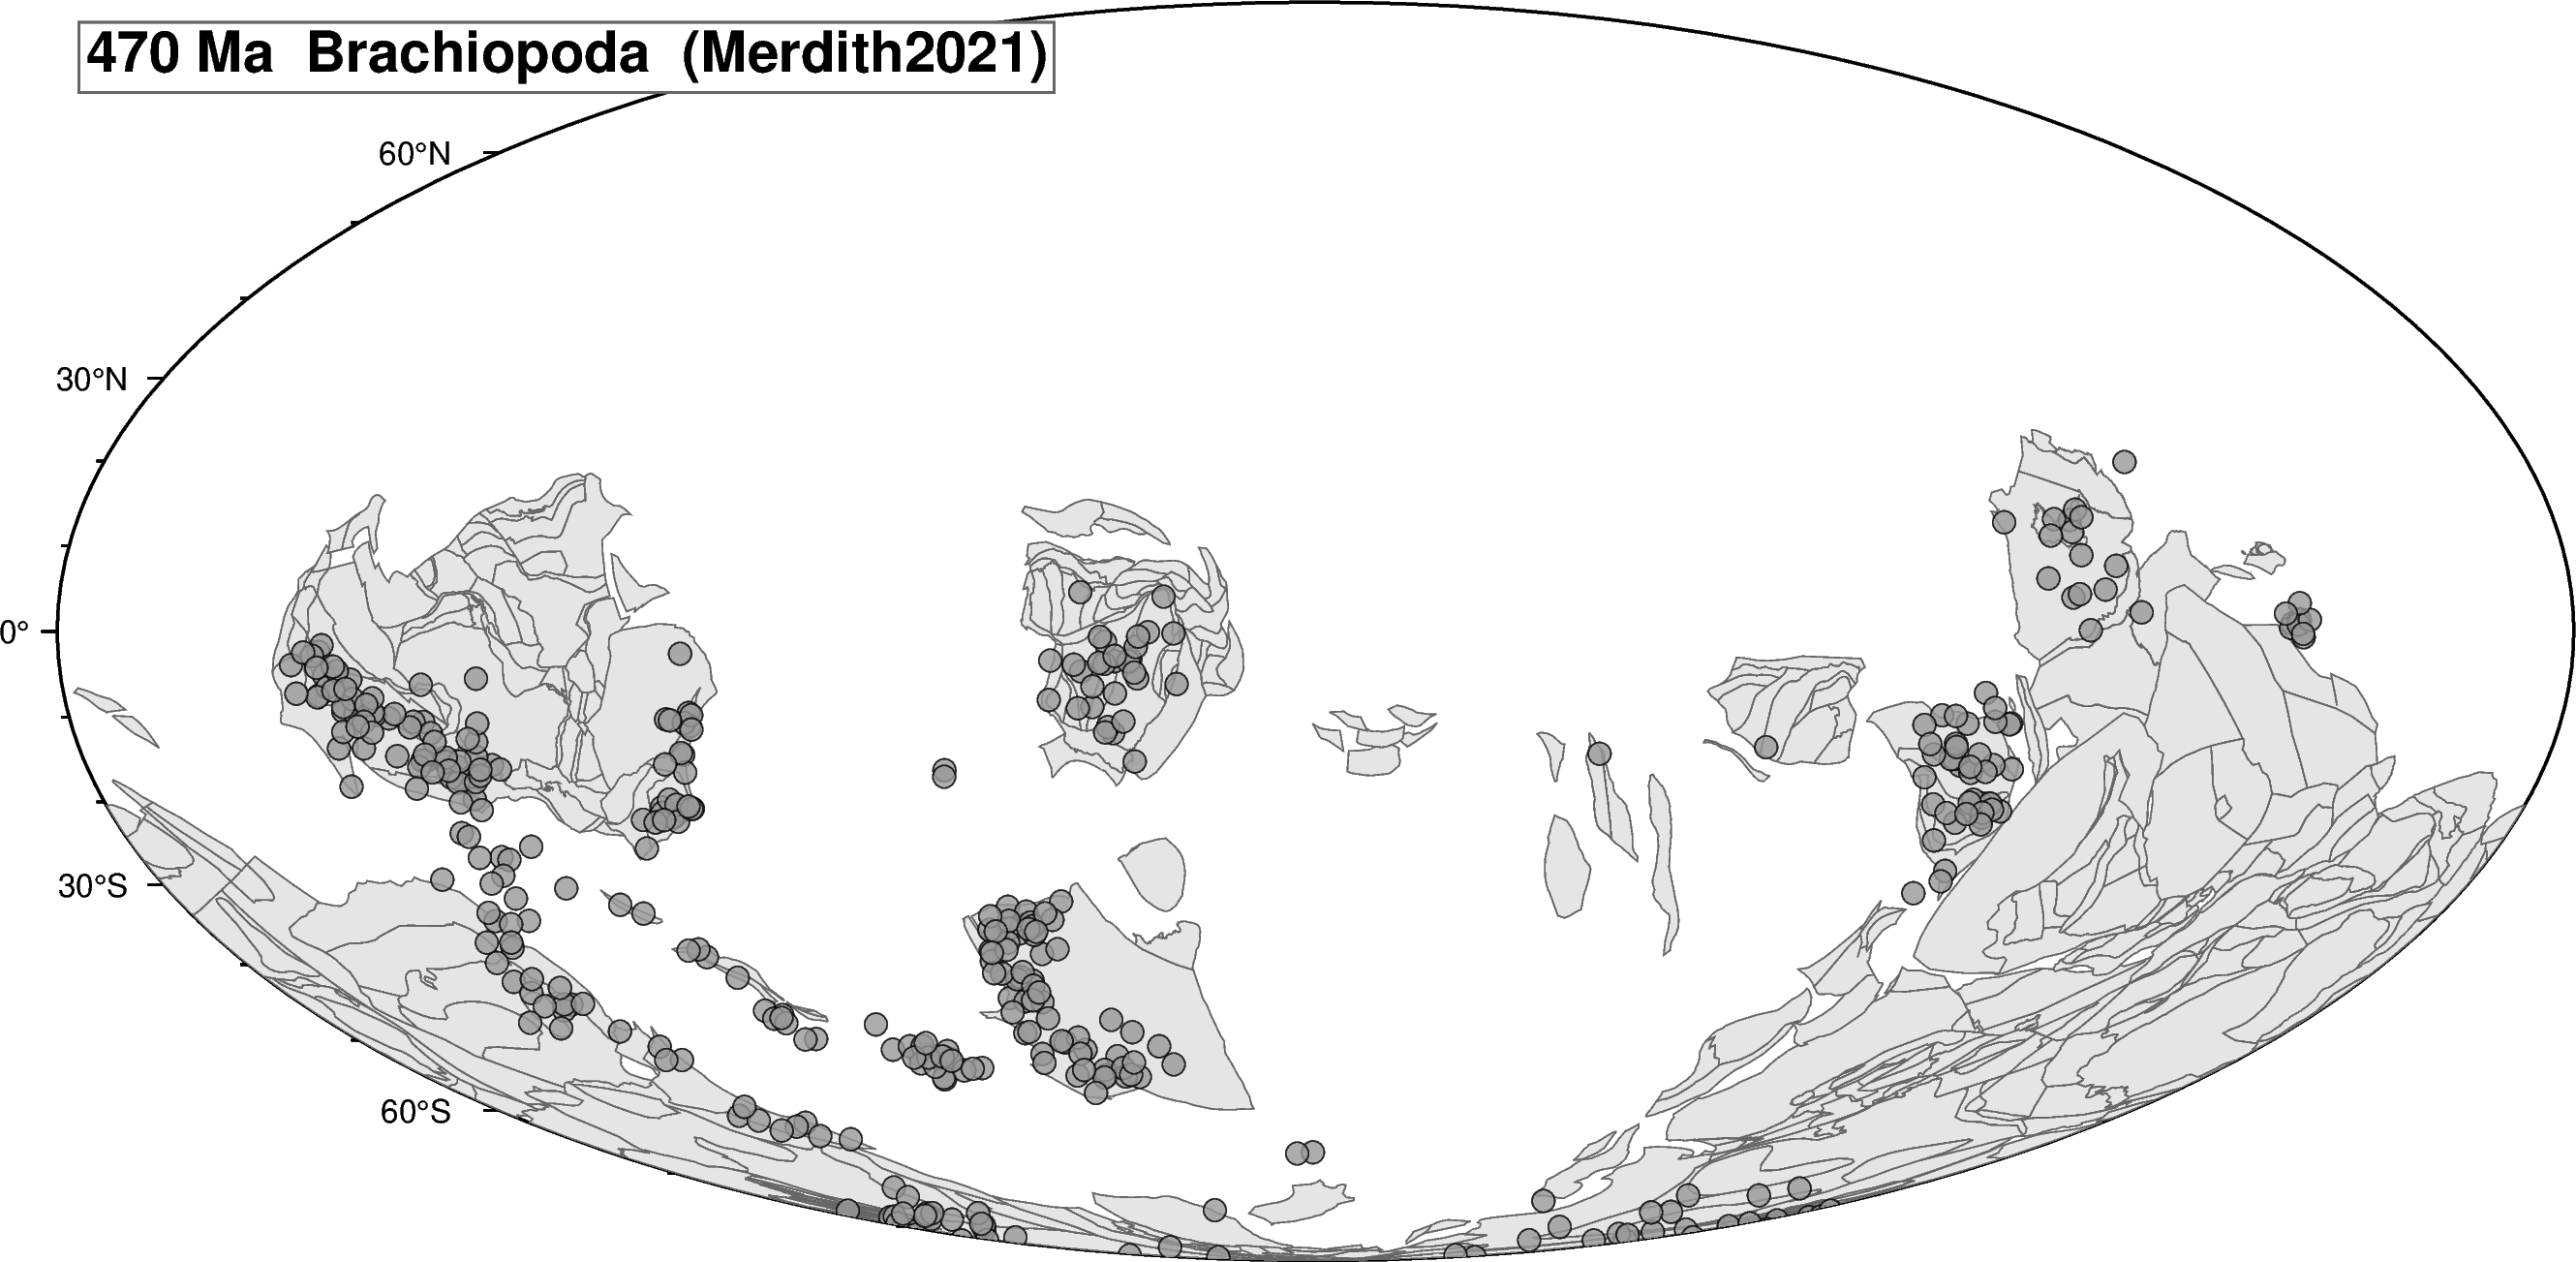

  total occurrences plotted: 380


In [12]:
# Cell 5 — render
LITH_COLOURS = {"siliciclastic": "orange",
                "carbonate":     "royalblue",
                "mixed":         "gray60",
                "unknown":       "gray85"}

gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(TARGET_TIME),
)
engine = gplately.PygmtPlotEngine()

fig = pygmt.Figure()
fig.basemap(region="d", projection="W0/22c", frame=["af"])
engine.plot_geo_data_frame(fig, gplot.get_continents(),
                           fill="gray90", pen="0.3p,gray40")
for lith, colour in LITH_COLOURS.items():
    sub = occ[occ["lithology"] == lith]
    if len(sub) == 0: continue
    fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"],
             style="c0.20c", fill=colour, pen="0.3p,black", transparency=20)

fig.text(text=f"{TARGET_TIME:.0f} Ma  {TAXON_NAME}  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
print(f"  total occurrences plotted: {len(occ)}")


## What the figure shows

A Mollweide paleo-Earth map at `TARGET_TIME` Ma with PBDB (https://paleobiodb.org/) occurrences of `TAXON_NAME` reconstructed to their paleo-positions and colour-coded by their joined Macrostrat (https://macrostrat.org/) lithology (carbonate, siliciclastic, evaporite, etc.). The legend / colourbar records the lithology palette; the in-frame stamp records the target age, taxon, and plate model.

What to read off:

- **Spatial concentration** in particular paleo-latitude bands or basins reveals the taxon's preferred paleo-environment at this age.
- **Lithology preference** — if the occurrence cloud is dominated by one lithology colour, the taxon was facies-specific (a carbonate-platform or shelf-sand obligate); if multiple colours coexist, the taxon was facies-tolerant.
- **Empty regions** are not necessarily evidence of absence — they may reflect the limits of the joined PBDB+Macrostrat sampling rather than the taxon's true paleo-range. The Extend-this section suggests sweeping `TARGET_TIME` to surface temporal sampling biases.

The joined dataset is the basic unit for paleo-biogeographic facies analysis: every occurrence is paired with its host rock's lithology, and the map projects the joined record into deep-time paleogeography.


## Extend this

- **Different taxonomic group.** Swap `TAXON_NAME` to `"Trilobita"`, `"Graptolithina"`, `"Conodonta"`, or anything else PBDB (https://paleobiodb.org/) knows about. The lithological-affinity pattern differs by group.
- **Sweep ages.** Loop `TARGET_TIME` from 540 to 440 Ma in 10 Myr steps and animate.
- **Per-lithology paleo-latitude distribution.** Add a side panel showing the histogram of paleo-latitudes for each lithology class — the latitudinal-belt segregation of carbonate vs siliciclastic facies should be visible.
- **Cross-reference T33 + T05.** T33 plots Macrostrat (https://macrostrat.org/) sedimentary units in paleo-position (rocks); T05 plots cryptospore localities in paleo-position (fossils, restricted to one group); T34 joins fossils to rocks. The three together cover the full litho-biogeography stack.

## References

- Carrasco, M.A. et al. (2018). The Paleobiology Database (https://paleobiodb.org/). *JOSS* 3, 1270.
- Peters, S.E. et al. (2018). Macrostrat. *G3* 19, 1393–1409.
- Kocsis, A.T. (2020). Reconstructing PBDB occurrences in R. https://plannapus.github.io/blog/2020-11-09.html
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
- Cao, X., Collins, A.S., Pisarevsky, S., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024). A deep-time Phanerozoic to Proterozoic plate motion model. *Earth System Science Data* 16, 4007–4032. https://doi.org/10.5194/essd-16-4007-2024

## See also: rgplates (the R-language equivalent)

The R-side PBDB-reconstruction workflow that inspired this notebook is now packaged into Kocsis, Raja, Williams & Dowding's [`rgplates`](https://github.com/GPlates/rgplates) — see in particular vignette 5 (*Reconstruction with data from the chronosphere*) for the production version of the workflow described in the 2020 blog post we cite as the inspiration. The Python recipe here gives the same PBDB-rotation behaviour for users whose downstream stack is `pandas` / `gplately` / `pygmt`.
